In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import os

2026-03-16 19:27:48.233794: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773689268.509690      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773689268.589102      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773689269.273156      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773689269.273222      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773689269.273225      55 computation_placer.cc:177] computation placer alr

In [4]:
d = 3 #hilbert space dimensions

input_dim = d**2
output_dim = d**2
save_dir = f'/kaggle/working/dataset_d{d}'

X_train =np.load(os.path.join(save_dir, "X_train.npy"))
Y_train =np.load(os.path.join(save_dir, "Y_train.npy"))
X_val=np.load(os.path.join(save_dir, "X_val.npy"))
Y_val=np.load(os.path.join(save_dir, "Y_val.npy"))
X_test=np.load(os.path.join(save_dir, "X_test.npy"))
Y_test=np.load(os.path.join(save_dir, "Y_test.npy"))

In [5]:
import numpy as np

def corrupt_data(X, gamma, method='random'):
    """
    Corrupt a fraction gamma of the samples in X.
    method: 'random' – replace with a random probability vector from Dirichlet.
            'swap'   – replace with the vector of a randomly chosen other sample.
    """
    n = X.shape[0]
    X_corr = X.copy()
    mask = np.random.rand(n) < gamma
    n_corr = mask.sum()
    if method == 'random':
        # Dirichlet(1,1,...,1) gives uniform random probabilities
        X_corr[mask] = np.random.dirichlet(np.ones(X.shape[1]), size=n_corr)
    elif method == 'swap':
        # For each corrupted sample, pick a random different index and swap
        for idx in np.where(mask)[0]:
            other = np.random.choice([i for i in range(n) if i != idx])
            X_corr[idx] = X[other]
    return X_corr

gamma = 0.1
X_test = corrupt_data(X_test, gamma, method='random')

In [10]:
d = 3 #hilbert space dimensions

input_dim = d**2
output_dim = d**2

model =  models.Sequential(name=f"QST{d}")

model.add(layers.InputLayer(input_shape = (input_dim,)))

model.add(layers.Dense(200,activation ='relu'))
model.add(layers.Dense(180,activation ='relu'))
model.add(layers.Dense(180,activation ='relu'))
model.add(layers.Dense(160,activation ='relu'))
model.add(layers.Dense(160,activation ='relu'))
model.add(layers.Dense(160,activation ='relu'))
model.add(layers.Dense(160,activation ='relu'))
model.add(layers.Dense(200,activation ='relu'))

model.add(layers.Dense(output_dim, activation = 'tanh'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
2026-03-16 19:28:19.116096: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [11]:
optimizer = tf.keras.optimizers.Nadam(
    learning_rate = 0.001,
    beta_1 = 0.9,
    beta_2 = 0.999,
    epsilon = 1e-7
)

model.compile(optimizer=optimizer,
             loss='mse',
             metrics=['mae'])

model.summary()

Model: "QST3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │         2,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 180)            │        36,180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 180)            │        32,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 160)            │        28,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 160)            │        25,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 160)            │        25,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 160)            │        25,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 200)            │        32,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 9)              │         1,809 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,009 (824.25 KB)

 Trainable params: 211,009 (824.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stop= callbacks.EarlyStopping(
    monitor='val_loss',
    patience = 200,
    restore_best_weights= True,

    verbose=2
)


checkpoint = callbacks.ModelCheckpoint(
    filepath = f"best_moodel_d{d}.keras",
    monitor = 'vals_loss',
    save_best_only = True,
    verbose = 1
)

history = model.fit(
    X_train, Y_train,
    batch_size = 100,
    epochs = 2000,
    validation_data = (X_val, Y_val),
    callbacks = [early_stop, checkpoint],
    verbose = 1
)

test_loss, test_mae  = model.evaluate(X_test, Y_test, verbose = 0)

print(f"nTest loss (MSE): {test_loss:.6f}")
print(f"Test MAE: {test_mae:.6f}")

model.save(f"final_model_d{d}.keras")

Epoch 1/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0545 - mae: 0.1825 - val_loss: 0.0238 - val_mae: 0.1203
Epoch 2/2000
 8/80 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0231 - mae: 0.1184 

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with vals_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0213 - mae: 0.1130 - val_loss: 0.0153 - val_mae: 0.0911
Epoch 3/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0147 - mae: 0.0894 - val_loss: 0.0115 - val_mae: 0.0767
Epoch 4/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0121 - mae: 0.0793 - val_loss: 0.0109 - val_mae: 0.0744
Epoch 5/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0098 - mae: 0.0699 - val_loss: 0.0104 - val_mae: 0.0734
Epoch 6/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0091 - mae: 0.0668 - val_loss: 0.0091 - val_mae: 0.0685
Epoch 7/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0091 - mae: 0.0668 - val_loss: 0.0075 - val_mae: 0.0611
Epoch 8/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0074 - mae: 0.0601 - val_loss: 0.0073 - val_mae: 0.0629
Epoch 9/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0064 - mae: 0.0564 - val_loss: 0.0047 - val_mae: 0.0468
Epoch 10/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.

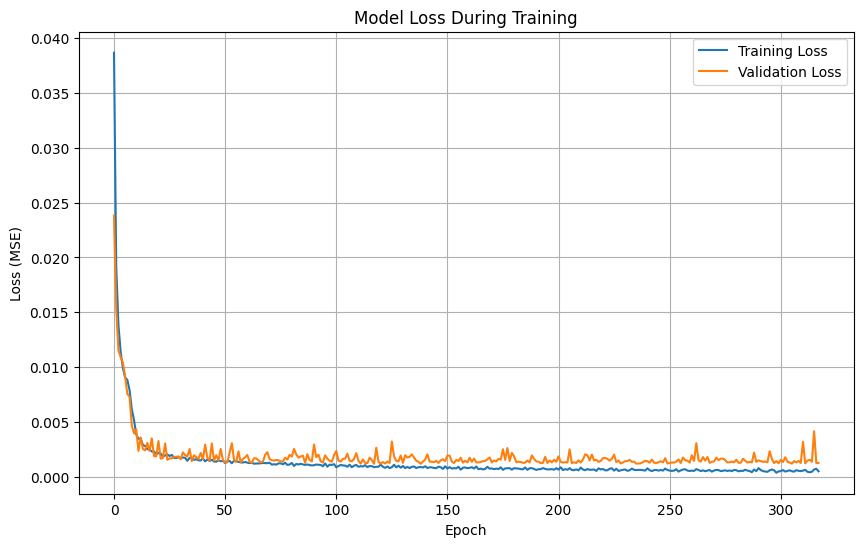

<Figure size 640x480 with 0 Axes>

In [13]:
import matplotlib.pyplot as plt

# Assuming you have 'history' from model.fit()
# history = model.fit(...)

# Plot training & validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Optional: save the figure
plt.savefig('loss_curve.png')

Metrics recorded: dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


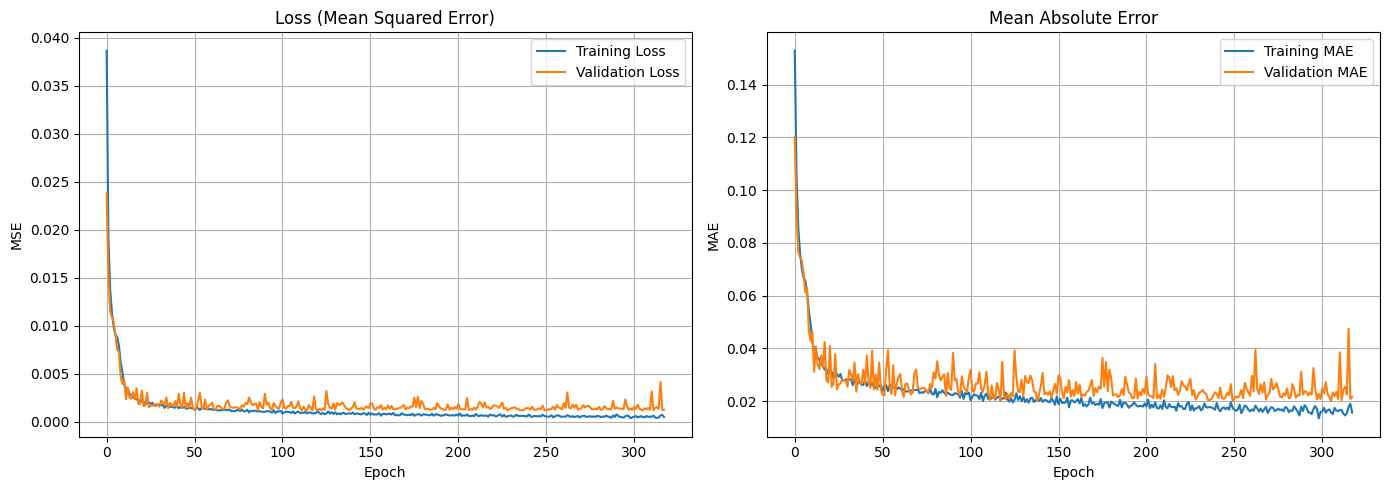

In [14]:
import matplotlib.pyplot as plt

# Assuming you have the 'history' object from model.fit()
# history = model.fit(...)

# Extract the history dictionary
hist = history.history

# Check available metrics (in case you added more)
print("Metrics recorded:", hist.keys())

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: Loss (MSE) ---
ax1.plot(hist['loss'], label='Training Loss', linewidth=1.5)
ax1.plot(hist['val_loss'], label='Validation Loss', linewidth=1.5)
ax1.set_title('Loss (Mean Squared Error)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE')
ax1.legend()
ax1.grid(True)

# --- Right plot: MAE ---
ax2.plot(hist['mae'], label='Training MAE', linewidth=1.5)
ax2.plot(hist['val_mae'], label='Validation MAE', linewidth=1.5)
ax2.set_title('Mean Absolute Error')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

**D = 7**

In [3]:
!pip install qutip

import numpy as np
import qutip as qt
from scipy.stats import multinomial
import os

# ----------------------------------------------------------------------
# Step 1 & 2: Set dimension and POVM size
# ----------------------------------------------------------------------
d = 3                     # dimension of the Hilbert space
N = d**2                  # number of POVM outcomes (informationally complete)
# For better performance you could use N = 2*d**2, but keep it simple here

# ----------------------------------------------------------------------
# Step 3: Construct a rank‑1 POVM via the square‑root measurement
#         using Haar‑random pure states.
# ----------------------------------------------------------------------
def generate_square_root_povm(d, N):
    """
    Generate a POVM {Π_i} with N outcomes.
    The construction follows the square‑root (pretty good) measurement:
      1. Draw N Haar‑random pure states |ψ_i⟩.
      2. Compute the frame operator S = Σ_i |ψ_i⟩⟨ψ_i|.
      3. Define Π_i = S^{-1/2} |ψ_i⟩⟨ψ_i| S^{-1/2}.
    Then Σ_i Π_i = I.
    """
    # 1. Generate Haar random kets
    kets = [qt.rand_ket(d) for _ in range(N)]

    # 2. Frame operator S
    S = sum(ket * ket.dag() for ket in kets)

    # 3. Inverse square root of S via eigen decomposition
    evals, evecs = S.eigenstates()
    # S^{-1/2} = Σ_k (1/√(λ_k)) |e_k⟩⟨e_k|
    S_inv_sqrt = sum((1 / np.sqrt(evals[k])) * evecs[k] * evecs[k].dag() for k in range(d))

    # 4. Build each POVM element
    povm = []
    for ket in kets:
        proj = ket * ket.dag()
        Pi = S_inv_sqrt * proj * S_inv_sqrt
        povm.append(Pi)

    return povm

print(f"Generating POVM for d={d} with N={N} outcomes...")
povm_qobj = generate_square_root_povm(d, N)          # list of Qobj
povm_np = [Pi.full() for Pi in povm_qobj]            # as numpy arrays for faster trace

# ----------------------------------------------------------------------
# Step 4 & 6: Helper functions for probabilities and Cholesky labels
# ----------------------------------------------------------------------
def probabilities(rho, povm_np):
    """Return the vector p_ℓ = Tr(ρ Π_ℓ) for a given density matrix ρ."""
    rho_mat = rho.full()
    p = [np.trace(rho_mat @ Pi).real for Pi in povm_np]
    return np.array(p, dtype=np.float32)

def cholesky_vector(rho):
    """
    Convert a density matrix ρ into a flat vector of its Cholesky parameters.
    ρ = L L^†, with L lower triangular.
    The vector contains (in order):
      - the d real diagonal entries of L,
      - for each i>j: the real and imaginary parts of L[i,j].
    Total length = d^2.
    """
    rho_mat = rho.full()
    # Ensure ρ is numerically positive (add small epsilon if needed)
    eigvals = np.linalg.eigvalsh(rho_mat)
    if np.min(eigvals) < 0:
        rho_mat += (-np.min(eigvals) + 1e-12) * np.eye(d)
    L = np.linalg.cholesky(rho_mat)   # L is lower triangular, complex
    vec = []
    # diagonal (real)
    for i in range(d):
        vec.append(L[i,i].real)
    # off-diagonals i>j (complex)
    for i in range(d):
        for j in range(i):
            vec.append(L[i,j].real)
            vec.append(L[i,j].imag)
    return np.array(vec, dtype=np.float32)

# ----------------------------------------------------------------------
# Step 2 (cont.): Generate random density matrices from the Ginibre ensemble
# ----------------------------------------------------------------------
def random_density_matrix_ginibre(d):
    """Draw a random density matrix according to ρ = X X† / Tr(X X†),
       where X is a complex Ginibre matrix (i.i.d. normal entries)."""
    # Using QuTiP's built‑in method (distribution='ginibre' is the default)
    return qt.rand_dm(d, density=1, distribution='ginibre')

# ----------------------------------------------------------------------
# Step 5 & 7: Create the dataset (training + validation + test)
# ----------------------------------------------------------------------
# For demonstration we use modest sizes. In practice you would scale up.
total_train_val = 10_000      # total training+validation samples
train_frac = 0.8
val_frac = 0.2
n_train = int(total_train_val * train_frac)
n_val   = total_train_val - n_train
n_test  = 1_000                # separate test set

print(f"Generating {total_train_val} training/validation states and {n_test} test states...")

X_train, Y_train = [], []
X_val,   Y_val   = [], []

# Mix of ideal (75%) and sampled (25%) probabilities
for i in range(total_train_val):
    if i % 1000 == 0:
        print(f"  Progress: {i}/{total_train_val}")

    rho = random_density_matrix_ginibre(d)
    p_ideal = probabilities(rho, povm_np)

    # Decide whether to use ideal or sampled probabilities
    if np.random.rand() < 0.75:          # 75% ideal
        p = p_ideal
    else:                                 # 25% sampled with random number of trials
        T = np.random.randint(d**2, 100_001)
        counts = multinomial.rvs(n=T, p=p_ideal, size=1)[0]
        p = counts / T

    y = cholesky_vector(rho)

    # Assign to training or validation
    if i < n_train:
        X_train.append(p)
        Y_train.append(y)
    else:
        X_val.append(p)
        Y_val.append(y)

# Convert to numpy arrays
X_train = np.array(X_train)
Y_train = np.array(Y_train)
X_val   = np.array(X_val)
Y_val   = np.array(Y_val)

print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")

# ----------------------------------------------------------------------
# Generate the separate test set (using ideal probabilities for simplicity)
# ----------------------------------------------------------------------
X_test, Y_test = [], []
for i in range(n_test):
    if i % 200 == 0:
        print(f"  Test progress: {i}/{n_test}")
    rho = random_density_matrix_ginibre(d)
    p_ideal = probabilities(rho, povm_np)
    y = cholesky_vector(rho)
    X_test.append(p_ideal)
    Y_test.append(y)

X_test = np.array(X_test)
Y_test = np.array(Y_test)
print(f"Test set: {X_test.shape}")

# ----------------------------------------------------------------------
# (Optional) Save to disk
# ----------------------------------------------------------------------
save_dir = f"dataset_d{d}"
os.makedirs(save_dir, exist_ok=True)
np.save(os.path.join(save_dir, "X_train.npy"), X_train)
np.save(os.path.join(save_dir, "Y_train.npy"), Y_train)
np.save(os.path.join(save_dir, "X_val.npy"),   X_val)
np.save(os.path.join(save_dir, "Y_val.npy"),   Y_val)
np.save(os.path.join(save_dir, "X_test.npy"),  X_test)
np.save(os.path.join(save_dir, "Y_test.npy"),  Y_test)

print(f"Dataset for d={d} saved in '{save_dir}'.")

Generating POVM for d=3 with N=9 outcomes...
Generating 10000 training/validation states and 1000 test states...
  Progress: 0/10000
  Progress: 1000/10000
  Progress: 2000/10000
  Progress: 3000/10000
  Progress: 4000/10000
  Progress: 5000/10000
  Progress: 6000/10000
  Progress: 7000/10000
  Progress: 8000/10000
  Progress: 9000/10000
Training set:   (8000, 9)
Validation set: (2000, 9)
  Test progress: 0/1000
  Test progress: 200/1000
  Test progress: 400/1000
  Test progress: 600/1000
  Test progress: 800/1000
Test set: (1000, 9)
Dataset for d=3 saved in 'dataset_d3'.
